# Geodesics around a Schwarzschild black hole

Hamiltonian formulation + RK4, following [`docs/derivation.md`](../docs/derivation.md). The
notebook only *uses* the `schwarzschild` package (see `src/schwarzschild/`); all the numerics live
there and are covered by the test suite.

For a static, spherically symmetric spacetime with $f(r) = 1 - 2M/r$ the equatorial geodesics
follow from the Hamiltonian $H = \tfrac12 g^{\mu\nu}p_\mu p_\nu = -\epsilon/2$ with the conserved
$E = -p_t$ and $L = p_\phi$. The state $\mathbf{y} = (t, r, \phi, p_r)$ obeys (eq. 24/25)

$$
\dot t = \frac{E}{f}, \qquad
\dot r = f\,p_r, \qquad
\dot\phi = \frac{L}{r^2}, \qquad
\dot p_r = -\frac{f'}{2}\left(\frac{E^2}{f^2} + p_r^2\right) + \frac{L^2}{r^3},
$$

where a dot is $d/d\lambda$ ($\lambda = \tau$ for massive particles). The mass-versus-photon choice
$\epsilon = 1$ or $0$ never appears in these equations: it only enters through the initial radial
momentum, fixed by the constraint $H = -\epsilon/2$.

Units are geometrized, $G = c = 1$, with $M = 1$, so the horizon is at $r = 2M$.
In the trajectory plots the black disk is the horizon, the dashed circle the photon sphere
($r = 3M$) and the dotted circle the ISCO ($r = 6M$).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from schwarzschild import (
    analytic,
    convergence_study,
    deflection_angle,
    effective_potential,
    energy_at_turning_point,
    initial_radial_momentum,
    integrate,
    photon_state,
    precession_per_orbit,
)
from schwarzschild.plotting import COLORS, apply_style, draw_black_hole, plot_photon_paths

apply_style()
M = 1.0  # all functions default to Schwarzschild(M=1); pass `metric=Schwarzschild(M)` to change it

## 1. Effective potential

Radial motion obeys $\dot r^2 + V_\text{eff}(r) = E^2$ with
$V_\text{eff} = f\,(\epsilon + L^2/r^2)$ (eq. 15).

* **Left, massive particles** ($\epsilon = 1$): for $L > \sqrt{12}\,M$ there is a maximum (unstable
  circular orbit) and a minimum (stable circular orbit); at $L = \sqrt{12}\,M$ they merge at the
  ISCO, $r = 6M$.
* **Right, photons** ($\epsilon = 0$, $E = 1$, $L = b$): the peak sits at $r = 3M$ and equals
  $b^2/27M^2$, hence the critical impact parameter $b_c = 3\sqrt{3}\,M$.

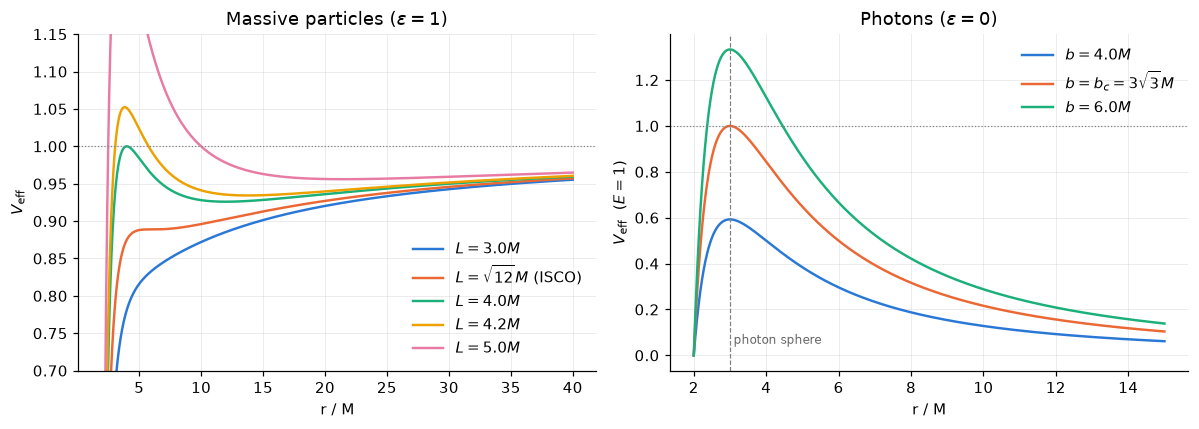

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

r = np.linspace(2.0 * M, 40.0 * M, 2000)
for L in [3.0, np.sqrt(12.0), 4.0, 4.2, 5.0]:
    label = r"$L=\sqrt{12}M$ (ISCO)" if np.isclose(L, np.sqrt(12)) else rf"$L={L:.1f}M$"
    ax1.plot(r, effective_potential(r, L, 1.0), label=label)
ax1.axhline(1.0, color="0.5", lw=0.8, ls=":")
ax1.set(ylim=(0.7, 1.15), xlabel="r / M", ylabel=r"$V_{\mathrm{eff}}$")
ax1.set_title(r"Massive particles ($\epsilon = 1$)")
ax1.legend()

b_c = analytic.critical_impact_parameter(M)
r = np.linspace(2.0 * M, 15.0 * M, 2000)
for b in [4.0, b_c, 6.0]:
    label = r"$b=b_c=3\sqrt{3}M$" if b == b_c else rf"$b={b:.1f}M$"
    ax2.plot(r, effective_potential(r, b, 0.0), label=label)
ax2.axhline(1.0, color="0.5", lw=0.8, ls=":")
ax2.axvline(3.0 * M, color="0.5", lw=0.8, ls="--")
ax2.text(3.1, 0.05, "photon sphere", color="0.4", fontsize=8)
ax2.set(xlabel="r / M", ylabel=r"$V_{\mathrm{eff}}$  ($E = 1$)")
ax2.set_title(r"Photons ($\epsilon = 0$)")
ax2.legend()
plt.tight_layout()
plt.show()

## 2. Circular orbit (massive particle)

For a circular orbit of radius $r_c$ (eq. 29)

$$
L = \sqrt{\frac{M r_c^2}{r_c - 3M}}, \qquad
E = \frac{1 - 2M/r_c}{\sqrt{1 - 3M/r_c}}, \qquad
p_{r,0} = 0 .
$$

The integration must keep $r = r_c$ and reproduce Kepler's law $d\phi/dt = \sqrt{M/r_c^3}$,
which is exact in Schwarzschild coordinates.

In [3]:
r_c = 10.0 * M
E_c, L_c = analytic.circular_orbit_constants(r_c, M)

circular = integrate([0.0, r_c, 0.0, 0.0], E_c, L_c, eps=1.0, h0=0.1, lam_max=2000.0)

omega_num = (circular.phi[-1] - circular.phi[0]) / (circular.t[-1] - circular.t[0])
print(f"E = {E_c:.8f}, L = {L_c:.8f}   (stopped: {circular.reason})")
print(f"max |r - r_c|   = {np.abs(circular.r - r_c).max():.2e}")
print(f"dphi/dt numeric = {omega_num:.10f}")
print(f"sqrt(M/r_c^3)   = {analytic.circular_orbit_angular_frequency(r_c, M):.10f}")
print(f"revolutions     = {circular.phi[-1] / (2 * np.pi):.2f}")

E = 0.95618289, L = 3.77964473   (stopped: lam_max)
max |r - r_c|   = 0.00e+00
dphi/dt numeric = 0.0316227766
sqrt(M/r_c^3)   = 0.0316227766
revolutions     = 12.03


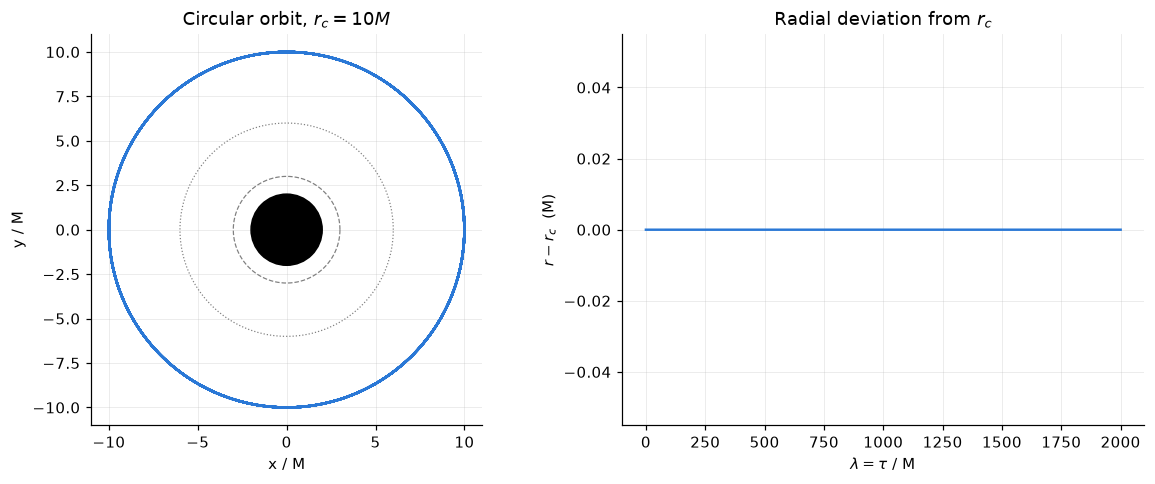

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.plot(*circular.xy(), color=COLORS[0])
draw_black_hole(ax1, M, isco=True)
ax1.set_title(rf"Circular orbit, $r_c = {r_c:.0f}M$")

ax2.plot(circular.lam, circular.r - r_c, color=COLORS[0])
ax2.set(xlabel=r"$\lambda = \tau$ / M", ylabel=r"$r - r_c$  (M)")
ax2.set_title(r"Radial deviation from $r_c$")
plt.tight_layout()
plt.show()

## 3. Bound orbit with periapsis precession

Start at apoapsis, $r_0 = 20M$ with $L = 4.2M$, $p_{r,0} = 0$ and $E = \sqrt{V_\text{eff}(r_0)}$.
The orbit is a rosette with $r \in [10.33M,\ 20M]$.

The periapsis advance per orbit is measured from consecutive periapsis passages ($p_r$ going from
negative to positive) and compared with the exact result. With $u = 1/r$ the orbit equation is
$(du/d\phi)^2 = 2M(u-u_1)(u-u_2)(u-u_3)$, which gives
$\Delta\phi = 4K(k^2)/\sqrt{2M(u_3-u_1)}$ in terms of the complete elliptic integral $K$
(see `analytic.precession_per_orbit`).

The weak-field estimate $6\pi M/[a(1-e^2)]$ is only a rough guide here: the orbit is too close to
the black hole for it to hold.

In [5]:
r0, L_b = 20.0 * M, 4.2 * M
E_b = energy_at_turning_point(r0, L_b)

bound = integrate([0.0, r0, 0.0, 0.0], E_b, L_b, eps=1.0, h0=0.05, lam_max=6000.0)

r_peri, r_apo = bound.r.min(), bound.r.max()
a, e = 0.5 * (r_peri + r_apo), (r_apo - r_peri) / (r_apo + r_peri)
numeric = precession_per_orbit(bound)
exact = analytic.precession_per_orbit(r_apo, r_peri, M)
weak_field = 6.0 * np.pi * M / (a * (1.0 - e**2))

print(f"E = {E_b:.8f}   r in [{r_peri:.4f}, {r_apo:.4f}]   a = {a:.3f} M, e = {e:.4f}")
print(f"periapsis passages measured : {len(numeric) + 1}")
print(
    f"precession / orbit, numeric : {numeric.mean():.9f} rad = {np.degrees(numeric.mean()):.3f} deg"
)
print(f"precession / orbit, exact   : {exact:.9f} rad")
print(f"relative difference         : {abs(numeric.mean() - exact) / exact:.1e}")
print(f"weak-field estimate         : {weak_field:.6f} rad (rough)")
print(f"max |C|                     : {np.abs(bound.constraint).max():.2e}")

E = 0.96937609   r in [10.3308, 20.0000]   a = 15.165 M, e = 0.3188
periapsis passages measured : 14
precession / orbit, numeric : 2.127094008 rad = 121.874 deg
precession / orbit, exact   : 2.127093985 rad
relative difference         : 1.1e-08
weak-field estimate         : 1.383542 rad (rough)
max |C|                     : 3.33e-16


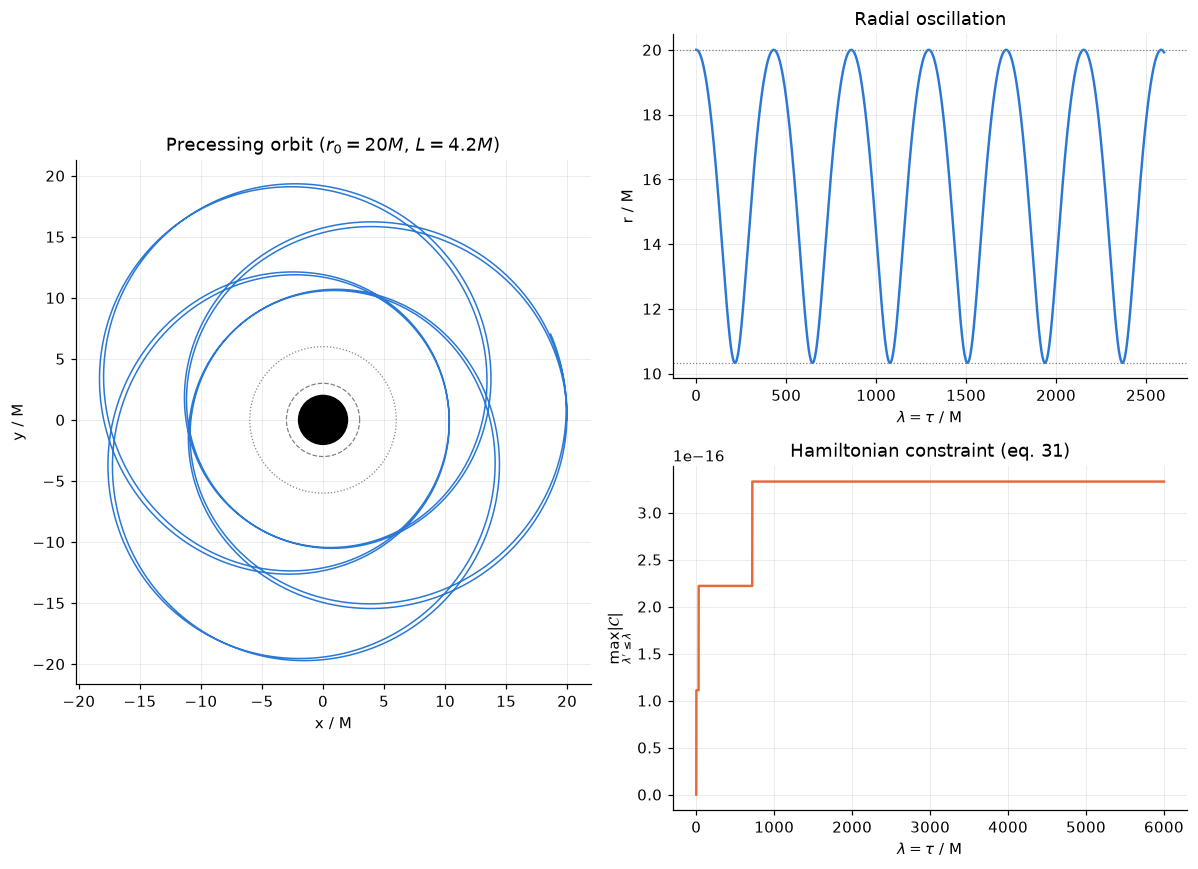

In [6]:
fig = plt.figure(figsize=(11, 8))
ax1 = fig.add_subplot(2, 2, (1, 3))
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 4)

shown = bound.lam <= 2600.0  # about six radial periods keep the rosette readable
x, y = bound.xy()
ax1.plot(x[shown], y[shown], color=COLORS[0], lw=1.0)
draw_black_hole(ax1, M, isco=True)
ax1.set_title(rf"Precessing orbit ($r_0 = {r0:.0f}M$, $L = {L_b}M$)")

ax2.plot(bound.lam[shown], bound.r[shown], color=COLORS[0])
ax2.axhline(r_peri, color="0.5", lw=0.8, ls=":")
ax2.axhline(r_apo, color="0.5", lw=0.8, ls=":")
ax2.set(xlabel=r"$\lambda = \tau$ / M", ylabel="r / M")
ax2.set_title("Radial oscillation")

# The per-step value sits at machine precision, so show its running maximum.
ax3.plot(bound.lam, np.maximum.accumulate(np.abs(bound.constraint)), color=COLORS[1])
ax3.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax3.set(xlabel=r"$\lambda = \tau$ / M", ylabel=r"$\max_{\lambda' \leq \lambda} |\mathcal{C}|$")
ax3.set_title("Hamiltonian constraint (eq. 31)")
plt.tight_layout()
plt.show()

## 4. Photons and the critical impact parameter

Photon paths depend only on $b = L/E$, so use $E = 1$ and $L = b$. A photon coming in from
$r_0 = 50M$ has $p_{r,0} = -\sqrt{1 - f(r_0)\,b^2/r_0^2}\,/\,f(r_0)$ (`photon_state`).

Prediction: $b < b_c = 3\sqrt3\,M \approx 5.196M$ is captured; $b > b_c$ is deflected and escapes.

In [7]:
print(f"b_c = {b_c:.6f} M\n")

r0_photon = 50.0 * M
photons = {}
for b in [3.0, 5.0, 5.19, 5.20, 6.0, 8.0]:
    traj = integrate(photon_state(r0_photon, b), 1.0, b, eps=0.0, h0=0.02, r_max=60.0)
    photons[b] = traj
    outcome = "captured" if traj.captured else traj.reason
    print(
        f"b = {b:5.2f} M: {outcome:<9s}  r_min = {traj.r.min():.4f} M, "
        f"delta_phi = {traj.phi[-1]:.4f} rad, "
        f"max relative constraint error = {traj.relative_constraint_error().max():.1e}"
    )

b_c = 5.196152 M

b =  3.00 M: captured   r_min = 2.0020 M, delta_phi = 1.6148 rad, max relative constraint error = 6.1e-08


b =  5.00 M: captured   r_min = 2.0020 M, delta_phi = 4.5245 rad, max relative constraint error = 5.9e-08
b =  5.19 M: captured   r_min = 2.0020 M, delta_phi = 8.0532 rad, max relative constraint error = 5.9e-08


b =  5.20 M: escaped    r_min = 3.0687 M, delta_phi = 9.7610 rad, max relative constraint error = 4.0e-12


b =  6.00 M: escaped    r_min = 4.4534 M, delta_phi = 4.6405 rad, max relative constraint error = 1.1e-12


b =  8.00 M: escaped    r_min = 6.7005 M, delta_phi = 3.7060 rad, max relative constraint error = 4.3e-13


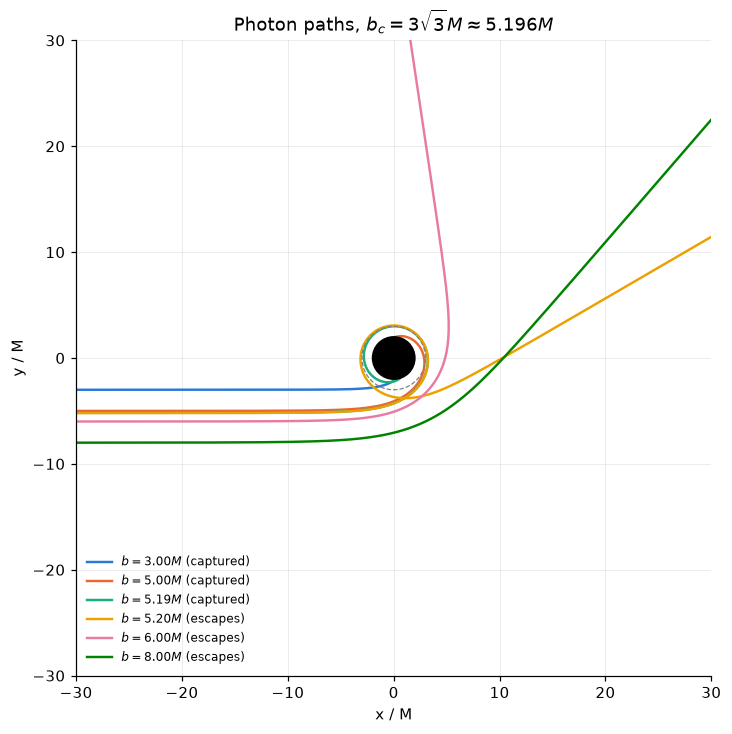

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 7.5))
plot_photon_paths(ax, photons, r0_photon, M)
ax.set_title(r"Photon paths, $b_c = 3\sqrt{3}M \approx 5.196M$")
plt.show()

### 4.1 Deflection angle versus impact parameter

For photons that escape, the total deflection is $\alpha = \Delta\phi - \pi$. In the weak field
$\alpha \approx 4M/b$ (Einstein), with higher-order corrections
$\alpha \approx 4M/b + \tfrac{15\pi}{4}(M/b)^2 + \tfrac{128}{3}(M/b)^3 + \dots$
Near $b_c$ the angle diverges logarithmically because the photon winds around the photon sphere
many times.

`deflection_angle` starts and ends the photon at $r = 1000M$ and adds back the straight-line angle
$\arcsin(b/r)$ covered outside that radius.

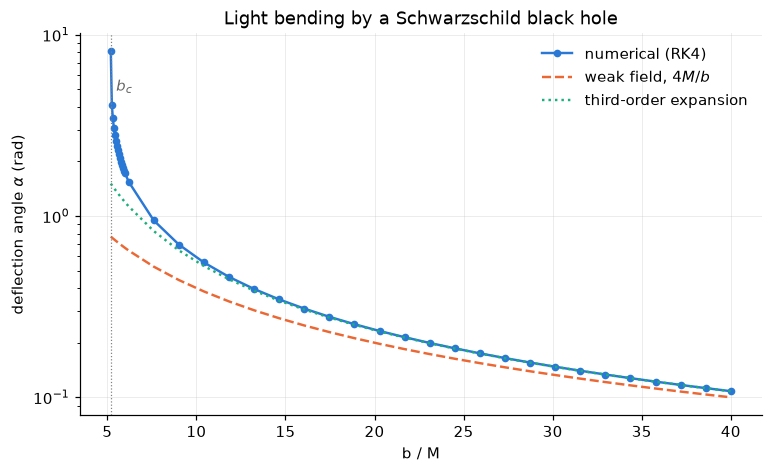

b =  20.0 M: numeric = 0.236136, 4M/b = 0.200000, 4th-order series = 0.235849
b =  30.0 M: numeric = 0.148248, 4M/b = 0.133333, 4th-order series = 0.148214


b =  40.0 M: numeric = 0.108104, 4M/b = 0.100000, 4th-order series = 0.108096


In [9]:
b_values = np.concatenate([np.linspace(b_c + 1e-3, 6.0, 15), np.linspace(6.2, 40.0, 25)])
alpha_numeric = np.array([deflection_angle(b) for b in b_values])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(b_values, alpha_numeric, "o-", ms=4, color=COLORS[0], label="numerical (RK4)")
ax.semilogy(
    b_values,
    [analytic.weak_field_deflection(b, M, order=1) for b in b_values],
    ls="--",
    color=COLORS[1],
    label=r"weak field, $4M/b$",
)
ax.semilogy(
    b_values,
    [analytic.weak_field_deflection(b, M, order=3) for b in b_values],
    ls=":",
    color=COLORS[2],
    label="third-order expansion",
)
ax.axvline(b_c, color="0.5", lw=0.8, ls=":")
ax.text(b_c + 0.3, alpha_numeric.max() * 0.6, r"$b_c$", color="0.4")
ax.set(xlabel="b / M", ylabel=r"deflection angle $\alpha$ (rad)")
ax.set_title("Light bending by a Schwarzschild black hole")
ax.legend()
plt.show()

for b in (20.0, 30.0, 40.0):
    print(
        f"b = {b:5.1f} M: numeric = {deflection_angle(b):.6f}, "
        f"4M/b = {analytic.weak_field_deflection(b, M, order=1):.6f}, "
        f"4th-order series = {analytic.weak_field_deflection(b, M, order=4):.6f}"
    )

## 5. RK4 convergence

The global error of RK4 is $\mathcal{O}(h^4)$: halving $h$ should reduce it about $2^4 = 16$ times.
The test integrates the precessing orbit up to $\lambda = 400M$ with fixed steps $h$, $h/2$, $h/4$,
$h/8$ and compares with a reference run at $h_\text{min}/16$.

      h      global error    ratio
  0.800    5.618e-09       nan
  0.400    3.259e-10     17.24
  0.200    1.972e-11     16.52
  0.100    1.400e-12     14.09

measured order = 3.996  (theory: 4)


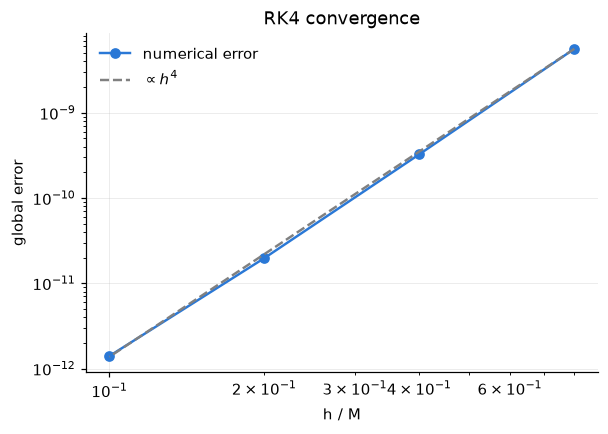

In [10]:
step_sizes = np.array([0.8, 0.4, 0.2, 0.1])
errors, order = convergence_study([0.0, r0, 0.0, 0.0], E_b, L_b, step_sizes, lam_end=400.0)

print("      h      global error    ratio")
for i, (h, err) in enumerate(zip(step_sizes, errors, strict=True)):
    ratio = errors[i - 1] / err if i > 0 else float("nan")
    print(f"{h:7.3f}    {err:.3e}    {ratio:6.2f}")
print(f"\nmeasured order = {order:.3f}  (theory: 4)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(step_sizes, errors, "o-", ms=6, color=COLORS[0], label="numerical error")
ax.loglog(
    step_sizes,
    errors[0] * (step_sizes / step_sizes[0]) ** 4,
    ls="--",
    color="0.5",
    label=r"$\propto h^4$",
)
ax.set(xlabel="h / M", ylabel="global error")
ax.set_title("RK4 convergence")
ax.legend()
plt.show()

## 6. Free simulation

Change the parameters below to run your own case. With `E = None` the energy is
$E = \sqrt{V_\text{eff}(r_0)}$ (start at a turning point, $p_{r,0} = 0$); otherwise $p_{r,0}$ is
computed from the constraint with direction `sigma`.

E = 0.959872, p_r0 = 0.000000, stopped: lam_max, lambda = 2000.05 M, steps = 40001
r in [10.3015, 12.0000] M,  max relative constraint error = 4.0e-16


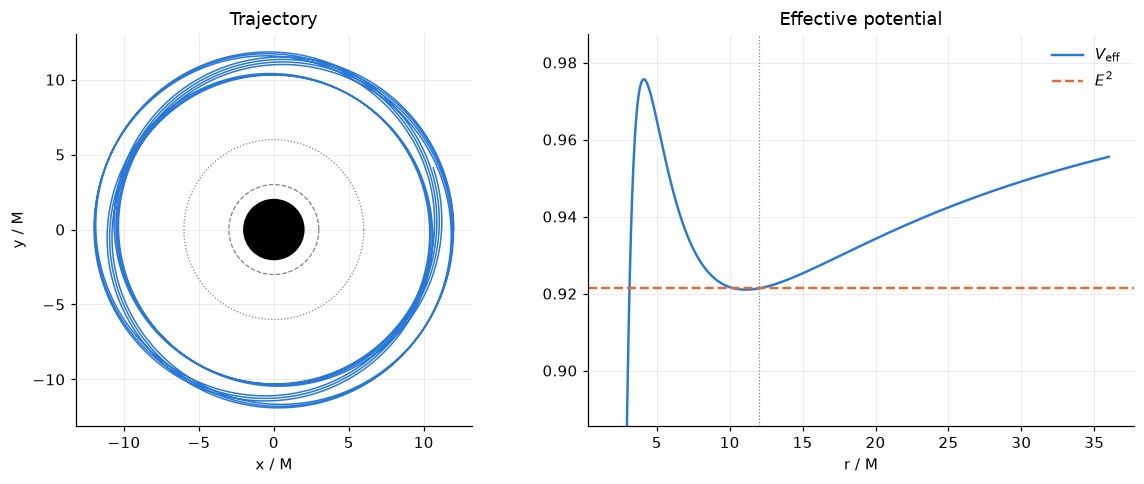

In [11]:
# ---- parameters ----
eps = 1.0  # 1 = massive particle, 0 = photon
r0 = 12.0  # initial radius (M)
L = 3.9  # specific angular momentum (M)
E = None  # specific energy; None -> start at a turning point
sigma = -1.0  # -1 ingoing, +1 outgoing (used only when E is given)
h0 = 0.05
lam_max = 2000.0
# --------------------

if E is None:
    E = energy_at_turning_point(r0, L, eps)
    p_r0 = 0.0
else:
    p_r0 = initial_radial_momentum(r0, E, L, eps, sign=sigma)

run = integrate([0.0, r0, 0.0, p_r0], E, L, eps, h0=h0, lam_max=lam_max, r_max=200.0)
print(
    f"E = {E:.6f}, p_r0 = {p_r0:.6f}, stopped: {run.reason}, "
    f"lambda = {run.lam[-1]:.2f} M, steps = {len(run.lam) - 1}"
)
print(
    f"r in [{run.r.min():.4f}, {run.r.max():.4f}] M,  "
    f"max relative constraint error = {run.relative_constraint_error().max():.1e}"
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.plot(*run.xy(), color=COLORS[0], lw=1.0)
draw_black_hole(ax1, M, isco=(eps == 1.0))
ax1.set_title("Trajectory")

rr = np.linspace(2.0 * M, max(3 * r0, 20.0), 2000)
V = effective_potential(rr, L, eps)
ax2.plot(rr, V, color=COLORS[0], label=r"$V_{\mathrm{eff}}$")
ax2.axhline(E**2, color=COLORS[1], ls="--", label=r"$E^2$")
ax2.axvline(r0, color="0.5", lw=0.8, ls=":")
# Zoom on the potential outside the photon sphere and on E^2
V_out = V[rr >= 3.0 * M]
lo, hi = min(V_out.min(), E**2), max(V_out.max(), E**2)
ax2.set_ylim(lo - 0.15 * (hi - lo), hi + 0.15 * (hi - lo))
ax2.set(xlabel="r / M")
ax2.set_title("Effective potential")
ax2.legend()
plt.tight_layout()
plt.show()